In [ ]:
!pip install --upgrade jupyter ipywidgets
!jupyter nbextension enable --py widgetsnbextension



columns: ['url', 'type']

rows: 651191

example:
                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement

label distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

unique labels: ['phishing', 'benign', 'defacement', 'malware']

label_map: {'phishing': 0, 'benign': 1, 'defacement': 2, 'malware': 3}

label counts after mapping:
label_id
1    428103
2     96457
0     94111
3     32520
Name: count, dtype: int64

Top characters in URLs: [('e', 2742501), ('t', 2303797), ('o', 2295984), ('a', 2176450), ('i', 1983297), ('/', 1921186), ('n', 1684380), ('c', 1683982), ('s', 1594139), ('r', 1

train:   0%|          | 0/8140 [00:00<?, ?it/s]

eval:   0%|          | 0/2035 [00:00<?, ?it/s]

Epoch 1/8 — train_loss: 0.2391, train_acc: 0.9186 | val_loss: 0.1385, val_acc: 0.9509


train:   0%|          | 0/8140 [00:00<?, ?it/s]

...

eval:   0%|          | 0/2035 [00:00<?, ?it/s]

Epoch 7/8 — train_loss: 0.1207, train_acc: 0.9551 | val_loss: 0.1016, val_acc: 0.9668


train:   0%|          | 0/8140 [00:00<?, ?it/s]

eval:   0%|          | 0/2035 [00:00<?, ?it/s]

Epoch 8/8 — train_loss: 0.1168, train_acc: 0.9564 | val_loss: 0.1029, val_acc: 0.9636


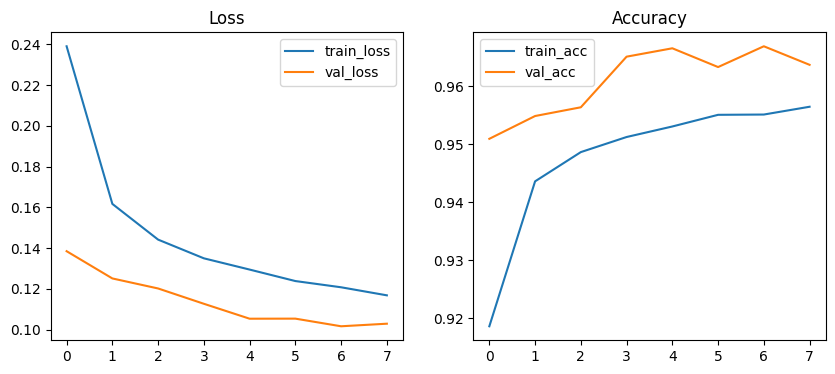


Classification report:
              precision    recall  f1-score   support

           0     0.8310    0.9481    0.8857     18822
           1     0.9911    0.9603    0.9755     85621
           2     0.9891    0.9949    0.9920     19292
           3     0.9756    0.9596    0.9675      6504

    accuracy                         0.9636    130239
   macro avg     0.9467    0.9657    0.9552    130239
weighted avg     0.9669    0.9636    0.9645    130239


Confusion matrix:
 [[17846   715   148   113]
 [ 3309 82223    55    34]
 [   81     8 19194     9]
 [  239    15     9  6241]]
Saved model to url_cnn_cpu.pth
sample url -> pred: 0 probs: [9.5184070e-01 1.6744673e-02 3.0827286e-02 5.8737356e-04]


In [1]:
# %% [markdown]
# Malicious URL Classifier (PyTorch, CPU)

#This Jupyter-style notebook trains a URL classifier (malicious vs benign) using PyTorch on **CPU**.

#**File expectation:** place `malicious_phish.csv` in the same directory as this notebook. The script expects a CSV with at least two columns: `url` and `label` (labels like `malicious` / `benign` or `phishing` / `legitimate`). Adjust `LABEL_COL` and `URL_COL` if needed.

#---

# %%
# Install required packages (uncomment and run if you don't have them)
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# !pip install pandas scikit-learn matplotlib tqdm

# %% [markdown]
# 1) Imports and constants
# %%
import os
import re
import math
from collections import Counter

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Constants (change if your CSV has different column names)
CSV_FILE = 'malicious_phish.csv'
URL_COL = 'url'
LABEL_COL = 'type'
MAX_LEN = 200   # max characters in sequence (truncate/pad)
BATCH_SIZE = 64
EMBED_DIM = 64
NUM_EPOCHS = 8
LR = 1e-3
DEVICE = torch.device('cpu')  # CPU-only as requested

# %% [markdown]
# 2) Load dataset and quick inspection
# %%
assert os.path.exists(CSV_FILE), f"CSV file not found: {CSV_FILE}"

df = pd.read_csv(CSV_FILE)
print('columns:', df.columns.tolist())
print('\nrows:', len(df))
print('\nexample:')
print(df.head())

# Basic label cleaning
print('\nlabel distribution:')
print(df[LABEL_COL].value_counts())

# %% [markdown]
# 3) Preprocessing utilities
# We'll lowercase URLs, optionally remove surrounding whitespace. We build a character-level vocabulary.
# %%

def clean_url(u):
    if pd.isna(u):
        return ''
    u = str(u).strip().lower()
    return u

# Apply cleaning
df['url_clean'] = df[URL_COL].apply(clean_url)

# If labels are not 0/1, map them
unique_labels = df[LABEL_COL].unique().tolist()
print('\nunique labels:', unique_labels)

# Create a mapping to 0/1 automatically if possible
label_map = {}
if set(unique_labels) <= set([0,1]):
    # already numeric 0/1
    label_map = None
else:
    # try to map anything containing 'mal'/'phish'/'bad' to 1
    # and anything containing 'benign'/'good'/'legit' to 0 — fallback: two unique values -> map them
    lowered = [str(x).lower() for x in unique_labels]
    if len(unique_labels) == 2:
        # map the one that looks malicious to 1
        if any('mal' in s or 'phish' in s or 'bad' in s or 'attack' in s for s in lowered):
            for orig, low in zip(unique_labels, lowered):
                label_map[orig] = 1 if ('mal' in low or 'phish' in low or 'bad' in low or 'attack' in low) else 0
        else:
            # default: map first -> 0, second -> 1
            label_map[unique_labels[0]] = 0
            label_map[unique_labels[1]] = 1
    else:
        # fallback: map unique values to integers starting at 0
        for i, val in enumerate(unique_labels):
            label_map[val] = i

if label_map is not None:
    print('\nlabel_map:', label_map)
    df['label_id'] = df[LABEL_COL].map(label_map)
else:
    df['label_id'] = df[LABEL_COL].astype(int)

print('\nlabel counts after mapping:')
print(df['label_id'].value_counts())

# %% [markdown]
# 4) Build character vocabulary
# We'll keep all characters present, but you can optionally limit to a set of allowed characters.
# %%

counter = Counter()
for u in df['url_clean']:
    counter.update(list(u))

# Show top characters
print('\nTop characters in URLs:', counter.most_common(20))

# Build mapping
# Reserve 0 for padding, 1 for unknown
chars = sorted(counter.keys())
char2idx = {c: i+2 for i, c in enumerate(chars)}
char2idx['<pad>'] = 0
char2idx['<unk>'] = 1
idx2char = {i: c for c, i in char2idx.items()}

vocab_size = max(char2idx.values()) + 1
print('\nvocab size:', vocab_size)

# %% [markdown]
# 5) Convert URLs to fixed-length sequences of indices
# %%

def url_to_seq(u, char2idx, max_len=MAX_LEN):
    seq = []
    for ch in u[:max_len]:
        seq.append(char2idx.get(ch, char2idx['<unk>']))
    if len(seq) < max_len:
        seq += [char2idx['<pad>']] * (max_len - len(seq))
    return seq

# Create sequences column
df['seq'] = df['url_clean'].apply(lambda u: url_to_seq(u, char2idx, MAX_LEN))

# Drop rows with empty URL (optional)
df = df[df['url_clean'].str.len() > 0].reset_index(drop=True)
print('\nrows after dropping empty urls:', len(df))

# %% [markdown]
# 6) Train / Validation split
# %%

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label_id'], random_state=42)
print('train size', len(train_df), 'test size', len(test_df))

# %% [markdown]
# 7) PyTorch Dataset & DataLoader
# %%

class UrlDataset(Dataset):
    def __init__(self, df):
        self.seqs = df['seq'].tolist()
        self.labels = df['label_id'].astype(int).tolist()
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        x = torch.tensor(self.seqs[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_ds = UrlDataset(train_df)
val_ds = UrlDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# %% [markdown]
# 8) Model definition (embedding + 1D conv + pooling)
# %%

class UrlClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=char2idx['<pad>'])
        self.conv = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=5, padding=2)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # x shape: (batch, seq_len)
        emb = self.embedding(x)           # (batch, seq_len, embed_dim)
        emb = emb.permute(0, 2, 1)        # (batch, embed_dim, seq_len)
        conv = self.conv(emb)             # (batch, out_channels, seq_len)
        pooled = self.pool(conv).squeeze(-1)  # (batch, out_channels)
        out = self.dropout(pooled)
        logits = self.fc(out)
        return logits

num_classes = len(df['label_id'].unique())
model = UrlClassifier(vocab_size=vocab_size+1, embed_dim=EMBED_DIM, num_classes=num_classes).to(DEVICE)
print(model)

# %% [markdown]
# 9) Loss, optimizer, optional class weights
# %%

# Compute class weights for imbalanced dataset
class_counts = df['label_id'].value_counts().sort_index().values
print('\nclass_counts =', class_counts)
class_weights = torch.tensor([sum(class_counts)/c for c in class_counts], dtype=torch.float)
print('class_weights =', class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# %% [markdown]
# 10) Training and evaluation loops
# %%

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    for x, y in tqdm(loader, desc='train', leave=False):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in tqdm(loader, desc='eval', leave=False):
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(y.cpu().numpy().tolist())
    return total_loss / len(loader.dataset), correct / len(loader.dataset), all_labels, all_preds

# %% [markdown]
# 11) Run training
# %%

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}/{NUM_EPOCHS} — train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}')

# %% [markdown]
# 12) Plot training curves
# %%

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='train_acc')
plt.plot(history['val_acc'], label='val_acc')
plt.legend()
plt.title('Accuracy')
plt.show()

# %% [markdown]
# 13) Final evaluation: classification report and confusion matrix
# %%

print('\nClassification report:')
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
print('\nConfusion matrix:\n', cm)

# %% [markdown]
# 14) Save model and artifacts
# %%

MODEL_PATH = 'url_cnn_cpu.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'char2idx': char2idx,
    'vocab_size': vocab_size,
    'MAX_LEN': MAX_LEN,
    'label_map': label_map
}, MODEL_PATH)
print('Saved model to', MODEL_PATH)

# %% [markdown]
# 15) Sample inference helper
# %%

def predict_url(url, model, char2idx, max_len=MAX_LEN):
    model.eval()
    seq = url_to_seq(clean_url(url), char2idx, max_len)
    x = torch.tensor([seq], dtype=torch.long)
    with torch.no_grad():
        logits = model(x)
        probs = nn.functional.softmax(logits, dim=1).cpu().numpy()[0]
        pred = int(np.argmax(probs))
    return pred, probs

# Example
sample_url = 'http://example.com/login.php?id=123'
pred, probs = predict_url(sample_url, model, char2idx)
print('sample url -> pred:', pred, 'probs:', probs)

# %% [markdown]
# ---
# Tips & next steps:
# - Try improving preprocessing (domain extraction, tokenization, feature engineering).
# - Try LSTM/GRU/Transformer models for sequence modeling.
# - Use stratified sampling, cross-validation, and more tuning for robust metrics.
# - If class labels are highly imbalanced, experiment with oversampling, focal loss, or stronger class weights.
# 
# If you want, I can export this notebook as a downloadable `.ipynb` file for you.
